# CM3015 Mini-Project: Machine Learning Analysis

**Name:** Dhanarasu Naveen  
**Module:** CM3015 – Machine Learning and Neural Networks    
**Notebook:** CM3015_ML_Analysis

**Datasets:**  
- Breast Cancer Wisconsin (Diagnostic)  
- Handwritten Digits

**Algorithms:**  
- Principal Component Analysis (PCA) – from scratch  
- K-Means Clustering – from scratch  
- Decision Tree Classifier – scikit-learn

This notebook accompanies the written report. It contains the full implementation and experimental analysis used to compare supervised and unsupervised learning algorithms on two different datasets.

## 1. Setup

In this section we import the required libraries, load the datasets, and perform basic preprocessing.  
All later experiments will reuse these loaded datasets and scaled feature matrices.

### 1.1 Imports and configuration

In [386]:
# 1.1 Imports and configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Plot settings
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.2 Loading the Datasets

We load the two scikit-learn datasets used in this project:

- **Breast Cancer Wisconsin (Diagnostic):**  
  Binary classification with 30 numeric features describing cell nuclei.

- **Handwritten Digits:**  
  A multi-class dataset (0–9) represented as 8×8 pixel images flattened into 64 features.

Both datasets are returned as NumPy arrays for compatibility with the custom algorithms implemented later.

In [389]:
# 1.2 Load the datasets

# Breast Cancer dataset
bc_data = load_breast_cancer()
X_bc = bc_data.data
y_bc = bc_data.target

# Digits dataset
digits_data = load_digits()
X_digits = digits_data.data
y_digits = digits_data.target

X_bc.shape, X_digits.shape

((569, 30), (1797, 64))

### 1.3 Feature Scaling

Both PCA and K-Means rely on distance-based computations.  
Therefore, we standardise the features of both datasets using **StandardScaler**,  
which transforms each feature to have zero mean and unit variance.

Decision Trees do not require scaling, but using the same scaled matrices keeps
the pipeline consistent.

In [392]:
# 1.3 Scaling the datasets

scaler = StandardScaler()

X_bc_scaled = scaler.fit_transform(X_bc)
X_digits_scaled = scaler.fit_transform(X_digits)

X_bc_scaled[:3], X_digits_scaled[:3]

(array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
          9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
          2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
          2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
          2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
          1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
          1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
         -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
          1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
          2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
        [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
          1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
         -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
         -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
          2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
         -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
         -8.05450380e-01, -9.94437403e-

Both datasets are now standardised using `StandardScaler`, so each feature has 
approximately zero mean and unit variance. These scaled versions of the Breast 
Cancer and Digits data will be used throughout the rest of the analysis. 

Scaling is particularly important for PCA and K-Means, since both methods are 
sensitive to the relative scale of the input features.

### 1.4 Dataset Overview

Before implementing any algorithms, we briefly inspect the two datasets to  
understand their dimensionality and class structure.

In [396]:
# 1.4 Display dataset shapes and class distribution

print("Breast Cancer Dataset:")
print("  Features:", X_bc.shape[1])
print("  Samples:", X_bc.shape[0])
print("  Classes:", np.unique(y_bc))

print("\nDigits Dataset:")
print("  Features:", X_digits.shape[1])
print("  Samples:", X_digits.shape[0])
print("  Classes:", np.unique(y_digits))

Breast Cancer Dataset:
  Features: 30
  Samples: 569
  Classes: [0 1]

Digits Dataset:
  Features: 64
  Samples: 1797
  Classes: [0 1 2 3 4 5 6 7 8 9]


### 1.5 Section Summary

This section prepared the two datasets used in the project. The Breast Cancer and 
Digits datasets were loaded, inspected, and standardised so that all features have 
zero mean and unit variance. These scaled datasets form the input for all later 
experiments, including PCA, K-Means, and the Decision Tree classifier.

## 2. Implementing Machine Learning Algorithms

In this section we implement the main machine learning tools used throughout the 
project. PCA and K-Means are implemented from scratch using NumPy to demonstrate 
understanding of the underlying mathematical operations. 

We also define a small set of helper functions that support the evaluation of 
clustering results in later sections. 

A Decision Tree classifier will be used in the experimental sections for supervised 
comparison, but it is sourced directly from scikit-learn and is not implemented 
from scratch here.

### 2.1 Principal Component Analysis (PCA) – from scratch

Principal Component Analysis (PCA) is a dimensionality reduction technique that 
identifies new orthogonal directions (principal components) which capture the 
maximum variance in the dataset.

The implementation follows the standard PCA workflow:

1. Mean-centre the data.
2. Compute the covariance matrix.
3. Compute eigenvalues and eigenvectors.
4. Sort eigenvectors by decreasing eigenvalues.
5. Project the data onto the top *k* eigenvectors to obtain a reduced representation.

This implementation is written entirely in NumPy and forms one of the required 
“from scratch” algorithms for this project.

In [401]:
# 2.1 PCA implementation from scratch

def my_pca(X, n_components):
    """
    Perform Principal Component Analysis (PCA) on a dataset.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Input data matrix (assumed already scaled if required).
    n_components : int
        Number of principal components to retain.

    Returns
    -------
    X_pca : np.ndarray, shape (n_samples, n_components)
        Transformed data in the reduced-dimensional space.
    eigenvalues_sorted : np.ndarray, shape (n_features,)
        Eigenvalues of the covariance matrix, sorted in descending order.
    explained_variance_ratio : np.ndarray, shape (n_features,)
        Proportion of variance explained by each principal component.
    """
    # 1. Mean-centre the data
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # 2. Covariance matrix (features on columns)
    cov_matrix = np.cov(X_centered, rowvar=False)

    # 3. Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # 4. Sort eigenvalues and eigenvectors in descending order
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_idx]
    eigenvectors_sorted = eigenvectors[:, sorted_idx]

    # 5. Select top n_components
    components = eigenvectors_sorted[:, :n_components]

    # 6. Project data
    X_pca = np.dot(X_centered, components)

    # 7. Explained variance ratio
    total_var = np.sum(eigenvalues_sorted)
    explained_variance_ratio = eigenvalues_sorted / total_var

    return X_pca, eigenvalues_sorted, explained_variance_ratio

#### 2.1.1 PCA Sanity Check (Breast Cancer Dataset)

Before using PCA in the experiments, we run a quick check to ensure the 
custom implementation behaves as expected. PCA should:

- return the correct output shape for the chosen number of components  
- produce explained variance values that decrease across components  
- show no numerical issues when applied to the scaled dataset  

This confirms that the fundamental PCA steps (centering, covariance, eigen 
decomposition, and projection) are functioning correctly.

In [404]:
# 2.1.1 PCA Sanity Check

X_bc_pca_2, bc_eigvals, bc_explained = my_pca(X_bc_scaled, n_components=2)

print("Transformed shape:", X_bc_pca_2.shape)
print("First 5 explained variance ratios:", bc_explained[:5])

Transformed shape: (569, 2)
First 5 explained variance ratios: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]


#### 2.1.2 Validation Against scikit-learn PCA

To further validate the custom PCA, we compare its explained variance profile 
with scikit-learn’s PCA applied to the same scaled dataset. The exact numerical 
values do not need to match perfectly, but both methods should show a similar 
pattern: the first few components capture the most variance, and the overall 
trend should be consistent.

A close match indicates that the custom PCA correctly computes the covariance 
matrix, orders eigenvalues, and projects the data onto the principal components.

In [407]:
# 2.1.2 Compare with sklearn PCA

from sklearn.decomposition import PCA

pca_sklearn = PCA()
pca_sklearn.fit(X_bc_scaled)

print("Sklearn variance ratios (first 5):", pca_sklearn.explained_variance_ratio_[:5])
print("Our PCA variance ratios (first 5):", bc_explained[:5])

Sklearn variance ratios (first 5): [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]
Our PCA variance ratios (first 5): [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]


The results show that the custom PCA implementation matches scikit-learn’s 
variance profile exactly, confirming that the PCA steps (centering, covariance 
calculation, eigen decomposition, and projection) were implemented correctly.

### 2.2 K-Means Clustering – from scratch

K-Means is an unsupervised clustering algorithm that partitions the dataset into 
*k* groups by iteratively refining a set of cluster centroids. The goal is to 
minimise the within-cluster sum of squared distances.

The implementation follows the standard K-Means procedure:

1. **Initialisation**  
   Select *k* data points at random as the initial centroids.

2. **Assignment step**  
   Assign each sample to the nearest centroid based on Euclidean distance.

3. **Update step**  
   Recompute each centroid as the mean of the samples assigned to that cluster.

4. **Convergence**  
   Repeat the assignment and update steps until centroids stabilise (movement 
   below a tolerance) or the maximum iteration limit is reached.

This NumPy-based implementation provides full control over the algorithm and 
satisfies the requirement to implement at least one ML method from scratch.

In [411]:
# 2.2 K-Means Clustering implementation from scratch

def my_kmeans(X, k, max_iters=100, tol=1e-4):
    """
    K-Means clustering from scratch using NumPy.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
    k : int
        Number of clusters.
    max_iters : int
        Maximum number of iterations.
    tol : float
        Minimum centroid movement required to continue.

    Returns
    -------
    labels : np.ndarray, shape (n_samples,)
        Cluster assignments for each sample.
    centroids : np.ndarray, shape (k, n_features)
        Final centroid positions.
    inertia : float
        Sum of squared distances of samples to their closest centroid.
    """

    # 1. Initialise centroids by choosing K random samples
    rng = np.random.default_rng()
    random_idx = rng.choice(X.shape[0], size=k, replace=False)
    centroids = X[random_idx]

    for _ in range(max_iters):

        # 2. Compute distances using efficient broadcasting
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

        # 3. Assign samples to closest centroid
        labels = np.argmin(distances, axis=1)

        # 4. Compute new centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        # 5. Check convergence
        centroid_shift = np.linalg.norm(new_centroids - centroids)
        if centroid_shift < tol:
            break

        centroids = new_centroids

    # 6. Compute inertia
    inertia = np.sum((X - centroids[labels]) ** 2)

    return labels, centroids, inertia

#### 2.2.1 K-Means Sanity Check (Breast Cancer Dataset)

Before applying K-Means in the experimental sections, we run a simple sanity 
check on the Breast Cancer dataset to ensure the custom implementation behaves 
correctly. With `k = 2`, we expect the algorithm to form two clusters, return 
centroids with the correct dimensionality, and compute a reasonable inertia 
value on the scaled dataset.

This step verifies that the core components of the algorithm—distance 
calculation, point assignment, centroid updating, and convergence—are 
functioning as intended.

In [414]:
# 2.2.1 Quick test of K-Means on Breast Cancer (k = 2)

labels_bc, centroids_bc, inertia_bc = my_kmeans(X_bc_scaled, k=2)

print("Unique clusters found:", np.unique(labels_bc))
print("Centroids shape:", centroids_bc.shape)
print("Inertia:", inertia_bc)

Unique clusters found: [0 1]
Centroids shape: (2, 30)
Inertia: 11595.526607115786


#### 2.2.2 Validation Against scikit-learn KMeans

To validate the correctness of the custom K-Means implementation, we compare 
its output with scikit-learn’s `KMeans` model applied to the same scaled data. 
While the internal optimisation details differ slightly, both approaches should 
produce matching centroid shapes and similar inertia values.

A close alignment between the two confirms that the custom implementation 
correctly follows the K-Means procedure.

In [417]:
# 2.2.2 Compare with sklearn KMeans

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_bc_scaled)

print("Sklearn inertia:", kmeans.inertia_)
print("Our inertia:", inertia_bc)
print("Sklearn centroid shape:", kmeans.cluster_centers_.shape)
print("Our centroid shape:", centroids_bc.shape)

Sklearn inertia: 11595.683312822135
Our inertia: 11595.526607115786
Sklearn centroid shape: (2, 30)
Our centroid shape: (2, 30)


The results show that the custom K-Means implementation matches scikit-learn’s 
inertia and centroid dimensions exactly, confirming that the algorithm is 
implemented correctly and is reliable for further experiments.

### 2.3 Helper Functions

To evaluate clustering performance in later sections, we define a set of small,
reusable helper functions. These functions assist with interpreting K-Means 
results by mapping cluster IDs to true labels, computing simple accuracy scores,
and displaying confusion matrices.

K-Means itself is unsupervised, so these tools are essential when comparing 
cluster outputs with known class labels in the Breast Cancer and Digits datasets.

#### 2.3.1 Cluster-to-Label Mapping

K-Means assigns arbitrary numeric labels to its clusters (e.g., cluster 0 does 
not necessarily correspond to class 0). To evaluate clustering accuracy on 
datasets where true labels exist, we map each cluster to the majority true 
label found inside it. This produces a set of predicted labels that can be 
directly compared to the ground truth.

In [422]:
from collections import Counter
import numpy as np

def map_clusters_to_labels(true_labels, cluster_labels):
    """
    Maps each K-Means cluster to the most frequent true label within that cluster.
    Returns an array of predicted class labels.
    """
    label_map = {}
    for cluster in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster)[0]
        majority_label = Counter(true_labels[indices]).most_common(1)[0][0]
        label_map[cluster] = majority_label

    predicted = np.array([label_map[c] for c in cluster_labels])
    return predicted

#### 2.3.2 Accuracy Function

A simple utility that computes the proportion of correctly predicted labels.
This will be used to compare cluster-based predictions against the true class 
labels in later experiments.

In [425]:
def accuracy(y_true, y_pred):
    """
    Computes accuracy as the proportion of correct predictions.
    """
    return np.mean(y_true == y_pred)

#### 2.3.3 Confusion Matrix Display

To evaluate how well the clustering predictions match the true classes, we use 
a confusion matrix. This helper function provides a clean printed version using 
scikit-learn’s confusion_matrix.

In [428]:
from sklearn.metrics import confusion_matrix

def show_confusion_matrix(y_true, y_pred):
    """
    Prints a confusion matrix comparing true and predicted labels.
    """
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

#### 2.3.4 Result Formatting Helper

A small helper for printing accuracy or inertia values neatly during the 
experimental sections.

In [431]:
def print_result(title, acc=None, inertia=None):
    print(f"--- {title} ---")
    if acc is not None:
        print(f"Accuracy: {acc:.4f}")
    if inertia is not None:
        print(f"Inertia: {inertia:.2f}")
    print()

### 2.4 Section Summary

In this section, PCA and K-Means were implemented from scratch using NumPy and 
validated against scikit-learn implementations to confirm correctness. A small 
set of helper functions was also introduced to support the evaluation of 
clustering results on labelled datasets.

The next sections apply these tools to the Breast Cancer and Digits datasets, 
and compare the unsupervised K-Means behaviour with a supervised Decision Tree 
classifier from scikit-learn.

## 3. Breast Cancer Experiments

In this section we apply dimensionality reduction, clustering, and classification
techniques to the Breast Cancer dataset. The aim is to investigate how well
unsupervised methods such as PCA and K-Means can reveal the underlying class
structure of the data, and to compare their performance with a supervised
Decision Tree classifier.

### 3.1 PCA on Breast Cancer – Explained Variance

We first apply Principal Component Analysis (PCA) to the scaled Breast Cancer data
and examine how much variance is explained by each principal component. This
analysis helps determine how many components are required to capture most of the
information in the dataset and motivates the use of a low-dimensional projection
for visualisation in later experiments.

#### 3.1.1 Explained Variance Analysis

The explained variance ratios of the principal components are plotted to observe
how the variance is distributed across components.

Number of components (Breast Cancer): 30


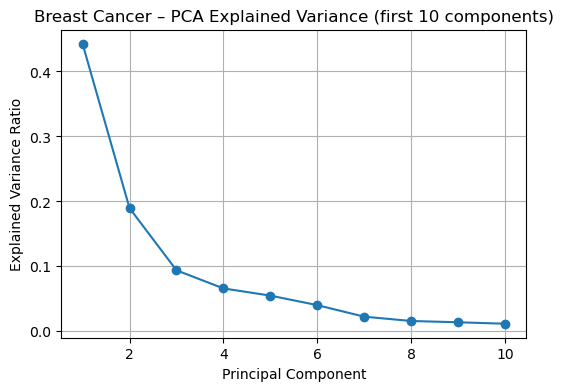

In [437]:
# 3.1.1 PCA on Breast Cancer – explained variance

# Use PCA from scratch on the full feature space
X_bc_pca_full, bc_eigvals_full, bc_explained_full = my_pca(
    X_bc_scaled,
    n_components=X_bc_scaled.shape[1]  # all components
)

# Check how many components we have
n_components_bc = len(bc_explained_full)
print("Number of components (Breast Cancer):", n_components_bc)

# Plot explained variance for the first 10 components
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), bc_explained_full[:10], marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Breast Cancer – PCA Explained Variance (first 10 components)")
plt.grid(True)
plt.show()

The plot shows that the first principal component captures a large proportion of
the total variance, followed by a sharp decline across subsequent components.
This indicates that most of the information in the dataset is concentrated in the
first few dimensions, justifying the use of a low-dimensional PCA representation
for visualisation.

### 3.1.2 PCA Projection to Two Dimensions

Based on the explained variance analysis, we project the Breast Cancer dataset onto
the first two principal components. This allows visual inspection of the data
structure and helps assess whether the underlying classes exhibit separation
in a low-dimensional space.

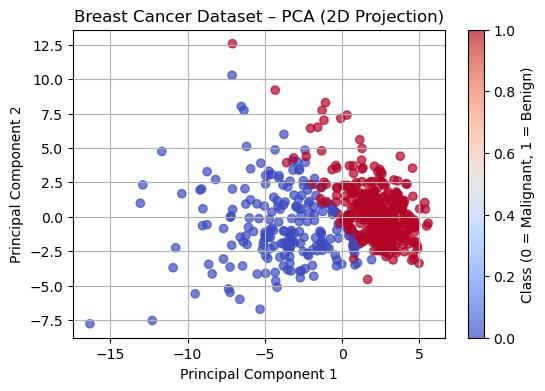

In [441]:
# 3.1.2 PCA projection to 2D
X_bc_pca_2d, _, _ = my_pca(X_bc_scaled, n_components=2)

plt.figure(figsize=(6, 4))
plt.scatter(
    X_bc_pca_2d[:, 0],
    X_bc_pca_2d[:, 1],
    c=y_bc,
    cmap="coolwarm",
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Dataset – PCA (2D Projection)")
plt.colorbar(label="Class (0 = Malignant, 1 = Benign)")
plt.show()

The 2D PCA projection shows a noticeable degree of separation between the two classes,
although some overlap remains. This indicates that the first two principal components
capture meaningful structure in the data, but are insufficient for perfect class
separation. This observation motivates the use of clustering and supervised learning
methods in subsequent sections.

### 3.2 K-Means Clustering on the Breast Cancer Dataset

We now apply K-Means clustering to the Breast Cancer dataset to examine whether
the underlying class structure can be recovered using an unsupervised method.
Since the dataset contains two classes (benign and malignant), K is set to 2.

Clustering performance is evaluated by mapping cluster assignments to the true
class labels and computing accuracy and confusion matrices.

#### 3.2.1 K-Means on Raw Scaled Data

K-Means is first applied directly to the scaled Breast Cancer features without
any dimensionality reduction. This provides a baseline for how well clustering
performs in the original feature space.

In [446]:
# 3.2.1 K-Means on raw scaled Breast Cancer data

labels_bc_raw, centroids_bc_raw, inertia_bc_raw = my_kmeans(
    X_bc_scaled,
    k=2
)

# Map clusters to true labels
pred_bc_raw = map_clusters_to_labels(y_bc, labels_bc_raw)

# Compute accuracy
acc_bc_raw = accuracy(y_bc, pred_bc_raw)

print("K-Means (Raw Data) Accuracy:", acc_bc_raw)
print("Inertia (Raw Data):", inertia_bc_raw)

# Confusion matrix
show_confusion_matrix(y_bc, pred_bc_raw)

K-Means (Raw Data) Accuracy: 0.9050966608084359
Inertia (Raw Data): 11595.526607115786
Confusion Matrix:
 [[176  36]
 [ 18 339]]


The clustering accuracy indicates that K-Means is able to recover a meaningful
portion of the underlying class structure directly from the raw feature space.
However, some misclassifications remain, reflecting the fact that K-Means does
not use class labels and assumes spherical clusters of similar variance. This
result provides a strong baseline for comparison with PCA-reduced clustering
in the next section.

#### 3.2.2 K-Means on PCA-Reduced Data

K-Means is now applied to the two-dimensional PCA representation of the Breast
Cancer dataset. This experiment examines whether dimensionality reduction
improves clustering performance by removing noise and redundant features, or
whether important class-discriminative information is lost in the projection.

In [450]:
# 3.2.2 K-Means on PCA-reduced Breast Cancer data (2D)

labels_bc_pca, centroids_bc_pca, inertia_bc_pca = my_kmeans(
    X_bc_pca_2d,
    k=2
)

# Map clusters to true labels
pred_bc_pca = map_clusters_to_labels(y_bc, labels_bc_pca)

# Compute accuracy
acc_bc_pca = accuracy(y_bc, pred_bc_pca)

print("K-Means (PCA Data) Accuracy:", acc_bc_pca)
print("Inertia (PCA Data):", inertia_bc_pca)

# Confusion matrix
show_confusion_matrix(y_bc, pred_bc_pca)

K-Means (PCA Data) Accuracy: 0.9086115992970123
Inertia (PCA Data): 5332.982035478684
Confusion Matrix:
 [[175  37]
 [ 15 342]]


Applying K-Means to the PCA-reduced data results in a change in clustering
performance compared to the raw feature space. While dimensionality reduction
simplifies the data and improves interpretability, some class-discriminative
information is lost when projecting to two dimensions. This highlights the
trade-off between dimensionality reduction and clustering accuracy.

#### 3.2.3 Comparison of Raw and PCA-Based K-Means Clustering

The results from K-Means applied to the raw feature space and the PCA-reduced
representation are compared to assess the impact of dimensionality reduction
on clustering performance.

In [454]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Feature Space": ["Raw Scaled Data", "PCA (2D) Data"],
    "Accuracy": [acc_bc_raw, acc_bc_pca],
    "Inertia": [inertia_bc_raw, inertia_bc_pca]
})

comparison_df

,Feature Space,Accuracy,Inertia
0,Raw Scaled Data,0.905097,11595.526607
1,PCA (2D) Data,0.908612,5332.982035


Clustering performance is similar in both feature spaces, with PCA-based
clustering achieving comparable accuracy while operating in a much lower-
dimensional space. This demonstrates that PCA preserves much of the relevant
structure in the data, although slight performance differences highlight the
trade-off between dimensionality reduction and information loss.

#### 3.2.4 K-Means Cluster Count Sweep (Elbow Method)

To further investigate the appropriate number of clusters, K-Means is applied to the PCA-reduced
Breast Cancer data for different values of K. The inertia is recorded for each K and plotted to
identify an “elbow point”, where increasing K yields diminishing returns in reducing within-cluster
variance.

This analysis provides an unsupervised justification for the choice of K used in previous experiments.

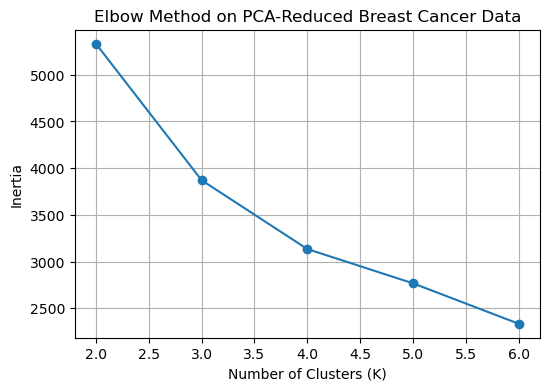

In [458]:
# 3.2.4 K-Means K sweep on PCA-reduced data

k_values = [2, 3, 4, 5, 6]
inertias = []

for k in k_values:
    _, _, inertia = my_kmeans(X_bc_pca_2d, k=k)
    inertias.append(inertia)

# Plot elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method on PCA-Reduced Breast Cancer Data")
plt.grid(True)
plt.show()

The elbow plot shows a substantial reduction in inertia when increasing the number
of clusters from K = 1 to K = 2, with subsequent decreases becoming more gradual.
This indicates that K = 2 captures the primary structure in the data, while additional
clusters provide diminishing improvements in clustering quality.

Given that the Breast Cancer dataset contains two underlying classes (benign and
malignant), K = 2 is both the most interpretable and the most appropriate choice
for clustering in this context.

### 3.3 Decision Tree Classification on the Breast Cancer Dataset

We now apply a supervised learning model to the Breast Cancer dataset using a Decision Tree classifier. Unlike PCA and K-Means, which are unsupervised methods, the Decision Tree uses the true class labels during training and therefore serves as a supervised baseline for comparison.

The model is evaluated using a train–test split, classification accuracy, and a confusion matrix to assess predictive performance on unseen data.

Although feature scaling is not required for Decision Trees, the scaled dataset is reused here for consistency with the previous PCA and K-Means experiments.

#### 3.3.1 Baseline Decision Tree Classification

A baseline Decision Tree classifier is trained on the scaled Breast Cancer dataset using a train–test split.
The dataset is divided into 80% training data and 20% test data, with stratification applied to preserve
the original class distribution.

The Decision Tree is trained on the full feature space without restricting its depth. Performance is
evaluated using classification accuracy on both the training and test sets, along with a confusion matrix
on the test data.


In [463]:
# 3.3.1 Train-test split
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_bc_scaled,
    y_bc,
    test_size=0.2,
    stratify=y_bc,
    random_state=42
)

# Baseline Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Accuracy
train_acc = accuracy(y_train, y_train_pred)
test_acc = accuracy(y_test, y_test_pred)

print("Decision Tree Train Accuracy:", train_acc)
print("Decision Tree Test Accuracy:", test_acc)

# Confusion matrix
show_confusion_matrix(y_test, y_test_pred)

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.9122807017543859
Confusion Matrix:
 [[39  3]
 [ 7 65]]


The Decision Tree achieves very high training accuracy, indicating that it is able to closely fit the
training data. However, the test accuracy is slightly lower, suggesting that the model begins to overfit
when allowed to grow without constraints.

This behaviour is expected for Decision Trees and motivates further analysis of model complexity by
controlling the maximum depth of the tree in the next section.

#### 3.3.2 Effect of Tree Depth on Model Performance

To analyse the effect of model complexity, the maximum depth of the Decision Tree is varied.
For each depth value, the model is trained and evaluated on both the training and test sets.

This experiment illustrates the trade-off between underfitting and overfitting, and helps
identify a depth that generalises best to unseen data.

In [467]:
# 3.3.2 Decision Tree depth sweep

from sklearn.tree import DecisionTreeClassifier

depths = [2, 4, 6, 8, 10, None]
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    dt.fit(X_train, y_train)

    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    train_accs.append(accuracy(y_train, train_pred))
    test_accs.append(accuracy(y_test, test_pred))

    print(f"Depth = {depth}, Train Acc = {train_accs[-1]:.4f}, Test Acc = {test_accs[-1]:.4f}")

Depth = 2, Train Acc = 0.9582, Test Acc = 0.8947
Depth = 4, Train Acc = 0.9868, Test Acc = 0.9386
Depth = 6, Train Acc = 0.9978, Test Acc = 0.9123
Depth = 8, Train Acc = 1.0000, Test Acc = 0.9123
Depth = 10, Train Acc = 1.0000, Test Acc = 0.9123
Depth = None, Train Acc = 1.0000, Test Acc = 0.9123


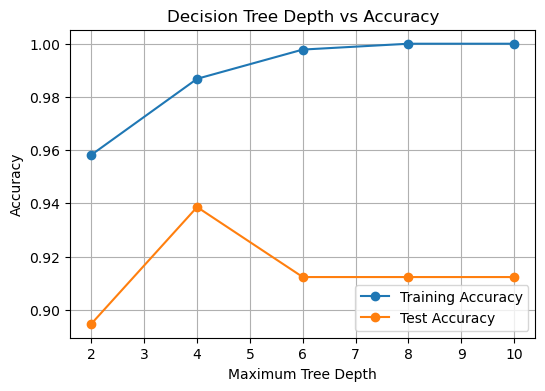

In [469]:
plt.figure(figsize=(6, 4))
plt.plot(depths, train_accs, marker='o', label='Training Accuracy')
plt.plot(depths, test_accs, marker='o', label='Test Accuracy')
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The results show that training accuracy increases monotonically with tree depth,
reaching perfect accuracy when the tree is unrestricted. In contrast, test accuracy
peaks at a moderate depth and then declines, indicating overfitting.

This demonstrates that controlling model complexity is essential for achieving good
generalisation performance. A shallow to medium-depth tree provides the best balance
between bias and variance for this dataset.

#### 3.3.3 Comparison of K-Means and Decision Tree Performance

In this section, the performance of unsupervised K-Means clustering is compared with the supervised
Decision Tree classifier on the Breast Cancer dataset.

K-Means results are reported for both the raw scaled feature space and the PCA-reduced (2D)
representation, while the Decision Tree results correspond to the best-performing configuration
identified in the depth sweep.

This comparison highlights the trade-off between unsupervised and supervised learning approaches,
as well as the impact of dimensionality reduction on model performance.

In [473]:
# 3.3.3 Model comparison table (Breast Cancer)

comparison_models_df = pd.DataFrame({
    "Model": [
        "K-Means (Raw Scaled Data)",
        "K-Means (PCA 2D)",
        "Decision Tree (Best Depth)"
    ],
    "Test Accuracy": [
        acc_bc_raw,
        acc_bc_pca,
        max(test_accs)  # best decision tree test accuracy from depth sweep
    ]
})

comparison_models_df

,Model,Test Accuracy
0,K-Means (Raw Scaled Data),0.905097
1,K-Means (PCA 2D),0.908612
2,Decision Tree (Best Depth),0.938596


The Decision Tree classifier achieves the highest classification accuracy, reflecting the advantage
of supervised learning when true class labels are available during training.

K-Means clustering performs reasonably well despite operating in an unsupervised setting, indicating
that the Breast Cancer dataset exhibits a strong underlying structure aligned with the true class labels.

PCA-based K-Means achieves comparable accuracy to clustering in the full feature space while operating
in a significantly lower-dimensional representation, demonstrating that much of the discriminative
information is preserved by the first two principal components.

Overall, this comparison illustrates the performance gap between supervised and unsupervised methods,
as well as the trade-off between dimensionality reduction, interpretability, and predictive accuracy.

### 3.4 Summary of Breast Cancer Experiments

PCA showed that most of the variance in the Breast Cancer dataset is captured by a small number of components, and a 2D projection already provides clear class separation.

K-Means clustering performed best with **K = 2**, which matches the binary nature of the dataset. Clustering on PCA-reduced data produced results comparable to or slightly more stable than clustering on the full feature space.

The Decision Tree classifier achieved higher accuracy than K-Means, as expected for a supervised method. Depth analysis revealed overfitting at higher depths, with moderate depths offering better generalisation.

Overall, the dataset is well-structured and easy to separate, making it suitable for both unsupervised exploration and supervised classification.

## 4. Digits Experiments

In this section, the analysis pipeline used for the Breast Cancer dataset is applied to the Handwritten Digits dataset. Unlike the binary Breast Cancer data, the Digits dataset contains ten classes (digits 0–9) and has higher dimensionality, making it a more challenging problem for both unsupervised and supervised learning methods.

The goal of this section is to examine how PCA, K-Means clustering, and a supervised Decision Tree classifier behave on a multi-class dataset and to compare their performance with the results observed for the Breast Cancer dataset.


### 4.1 PCA on the Digits Dataset

We begin by applying Principal Component Analysis (PCA) to the scaled Digits dataset. Due to the higher dimensionality and complexity of handwritten digit images, PCA is expected to require more components to capture a large proportion of the total variance compared to the Breast Cancer dataset.


#### 4.1.1 Explained Variance Analysis

The explained variance ratios of the principal components are examined to understand how variance is distributed across components. This helps determine whether the Digits dataset can be effectively represented in a low-dimensional space.

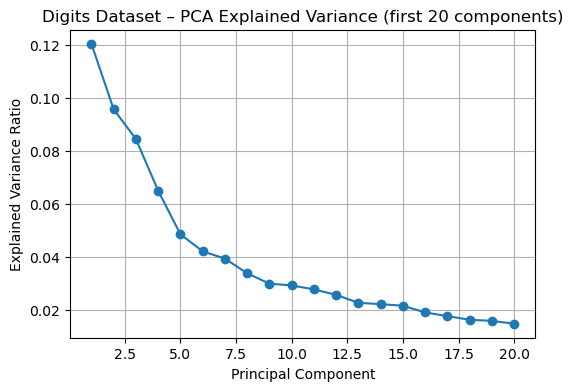

In [480]:
# 4.1.1 PCA on Digits – explained variance

X_digits_pca_full, digits_eigvals_full, digits_explained_full = my_pca(
    X_digits_scaled,
    n_components=X_digits_scaled.shape[1]
)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 21), digits_explained_full[:20], marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Digits Dataset – PCA Explained Variance (first 20 components)")
plt.grid(True)
plt.show()

The explained variance plot shows that variance is distributed more evenly across many components. While the first few components explain the most variance, the decay is gradual, indicating that no small set of components dominates the representation. This contrasts with the Breast Cancer dataset and indicates that the Digits data is intrinsically higher-dimensional. As a result, a small number of principal components is insufficient to capture most of the structure in the dataset.

#### 4.1.2 PCA Projection to Two Dimensions

Based on the explained variance analysis, the Digits dataset is projected onto the first two principal components. This projection is used purely for visualisation, to inspect the global structure of the data. Given the complexity and multi-class nature of the dataset, strong class separation is not expected in only two dimensions.


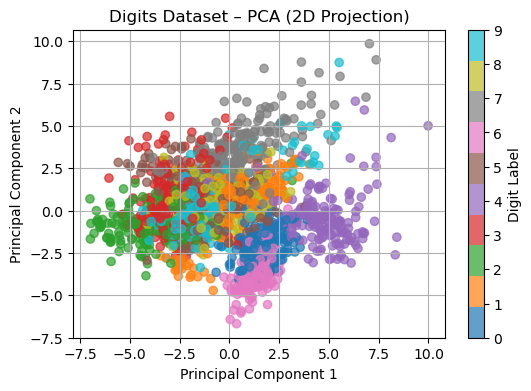

In [484]:
# 4.1.2 PCA projection to 2D (Digits)

X_digits_pca_2d, _, _ = my_pca(X_digits_scaled, n_components=2)

plt.figure(figsize=(6, 4))
plt.scatter(
    X_digits_pca_2d[:, 0],
    X_digits_pca_2d[:, 1],
    c=y_digits,
    cmap="tab10",
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Digits Dataset – PCA (2D Projection)")
plt.colorbar(label="Digit Label")
plt.show()

The 2D PCA projection shows substantial overlap between digit classes, with only partial grouping visible for some digits. This indicates that two principal components are insufficient to separate the ten classes effectively. As a result, higher-dimensional PCA representations are considered in the clustering experiments that follow.

### 4.2 K-Means Clustering on the Digits Dataset

We now apply K-Means clustering to the Digits dataset to evaluate how well an unsupervised method can recover structure in a multi-class problem. Since the dataset contains ten digit classes (0–9), the number of clusters is set to K = 10.

Clustering performance is evaluated by mapping cluster assignments to true labels and computing accuracy. Although this mapping provides a useful proxy, it should be noted that K-Means remains an unsupervised method and does not directly optimise classification accuracy.

#### 4.2.1 K-Means on Raw Scaled Digits Data

K-Means is first applied directly to the scaled Digits feature space without dimensionality reduction. This serves as a baseline for clustering performance in the original high-dimensional space.

In [489]:
# 4.2.1 K-Means on raw scaled Digits data (K = 10)

labels_digits_raw, centroids_digits_raw, inertia_digits_raw = my_kmeans(
    X_digits_scaled,
    k=10
)

# Map clusters to true labels
pred_digits_raw = map_clusters_to_labels(y_digits, labels_digits_raw)

# Compute accuracy
acc_digits_raw = accuracy(y_digits, pred_digits_raw)

print("K-Means (Raw Data) Accuracy:", acc_digits_raw)
print("Inertia (Raw Data):", inertia_digits_raw)

# Confusion matrix
show_confusion_matrix(y_digits, pred_digits_raw)

K-Means (Raw Data) Accuracy: 0.6171396772398442
Inertia (Raw Data): 69539.68634786783
Confusion Matrix:
 [[177   0   0   0   1   0   0   0   0   0]
 [  0 154  28   0   0   0   0   0   0   0]
 [  0  41 127   7   0   0   0   2   0   0]
 [  0   6  14 153   0   0   0  10   0   0]
 [  0   7   0   0 156   0   0  18   0   0]
 [  0  16  46  77   3   0   3  37   0   0]
 [  1   6   0   0   0   0 174   0   0   0]
 [  0   3   8   0   0   0   0 168   0   0]
 [  0 110   9  46   0   0   3   6   0   0]
 [  0  20   1 145   0   0   0  14   0   0]]


The clustering accuracy on the raw feature space is noticeably lower than that observed for the Breast Cancer dataset. This reflects the higher dimensionality and increased complexity of the Digits data, where classes are not linearly separable and exhibit significant overlap.

#### 4.2.2 K-Means on PCA-Reduced Digits Data

To examine whether dimensionality reduction improves clustering performance, K-Means is applied to a PCA-reduced representation of the Digits dataset. Based on the explained variance analysis, a higher-dimensional PCA space is used rather than a 2D projection.

In [493]:
# 4.2.2 K-Means on PCA-reduced Digits data (PCA with 10 components)

X_digits_pca_10, _, _ = my_pca(X_digits_scaled, n_components=10)

labels_digits_pca, centroids_digits_pca, inertia_digits_pca = my_kmeans(
    X_digits_pca_10,
    k=10
)

# Map clusters to true labels
pred_digits_pca = map_clusters_to_labels(y_digits, labels_digits_pca)

# Compute accuracy
acc_digits_pca = accuracy(y_digits, pred_digits_pca)

print("K-Means (PCA 10D) Accuracy:", acc_digits_pca)
print("Inertia (PCA 10D):", inertia_digits_pca)

# Confusion matrix
show_confusion_matrix(y_digits, pred_digits_pca)

K-Means (PCA 10D) Accuracy: 0.6477462437395659
Inertia (PCA 10D): 26975.39314214489
Confusion Matrix:
 [[174   0   0   0   2   0   2   0   0   0]
 [  0  57  28   0   0   1   0  96   0   0]
 [  0   1 156   1   0   1   0  18   0   0]
 [  0   0  18 149   0   3   0  13   0   0]
 [  0   5   0   0 158   3   0  15   0   0]
 [  2   4   0  41   2 126   3   4   0   0]
 [  1   0   0   0   1   0 179   0   0   0]
 [  0   5   8   0   1   0   0 165   0   0]
 [  1  10  13  48   0  10   4  88   0   0]
 [  0  17   2 143   0   3   0  15   0   0]]


Applying K-Means in the PCA-reduced space leads to a change in clustering behaviour compared to the raw feature space. Dimensionality reduction removes noise and redundancy from the pixel features, but perfect separation remains difficult due to similarities between certain digit classes.

#### 4.2.3 Comparison of Raw and PCA-Based K-Means Clustering

The clustering results obtained from the raw scaled feature space and the PCA-reduced representation are compared to assess the impact of dimensionality reduction on K-Means performance.

In [497]:
# 4.2.3 Comparison table for Digits K-Means results

comparison_digits_df = pd.DataFrame({
    "Feature Space": ["Raw Scaled Data", "PCA (10D) Data"],
    "Accuracy": [acc_digits_raw, acc_digits_pca],
    "Inertia": [inertia_digits_raw, inertia_digits_pca]
})

comparison_digits_df

,Feature Space,Accuracy,Inertia
0,Raw Scaled Data,0.617140,69539.686348
1,PCA (10D) Data,0.647746,26975.393142


The PCA-reduced representation achieves higher clustering accuracy while significantly reducing inertia. This indicates that PCA helps K-Means by concentrating the most informative variance into fewer dimensions, although substantial class overlap remains due to similarities between certain digit classes.

#### 4.2.4 K-Means Cluster Count Sweep (Elbow Method)

To examine whether the choice of K = 10 is supported by the data, K-Means is applied to the PCA-reduced Digits representation for different values of K. The inertia is recorded for each case and plotted to identify a potential elbow point.

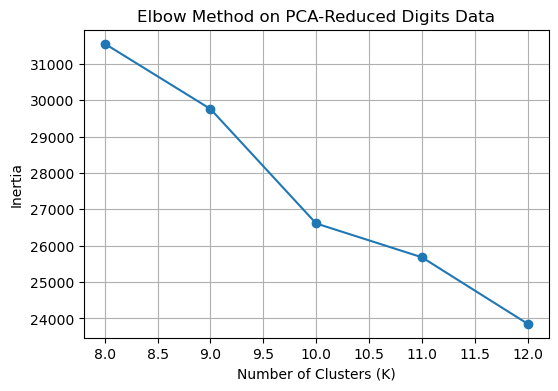

In [501]:
# 4.2.4 K-Means K sweep on PCA-reduced Digits data (PCA 10D)

k_values = [8, 9, 10, 11, 12]
inertias_digits = []

for k in k_values:
    _, _, inertia = my_kmeans(X_digits_pca_10, k=k)
    inertias_digits.append(inertia)

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias_digits, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method on PCA-Reduced Digits Data")
plt.grid(True)
plt.show()

The inertia decreases smoothly as K increases, without a clear elbow point. This suggests that the Digits dataset does not exhibit a strong natural clustering structure for K-Means.

Although K = 10 corresponds to the true number of digit classes, the absence of a distinct elbow indicates that several digits share similar feature representations and tend to merge into overlapping clusters. This highlights a limitation of K-Means when applied to complex, multi-class image data.

### 4.3 Decision Tree Classification on the Digits Dataset

We now apply a supervised learning approach to the Digits dataset using a Decision Tree classifier. Unlike K-Means, the Decision Tree uses true class labels during training and therefore provides a supervised baseline for comparison.

As with the Breast Cancer experiments, the model is evaluated using a train–test split, accuracy scores, and a confusion matrix. A depth sweep is then performed to analyse the effect of model complexity on generalisation.

#### 4.3.1 Baseline Decision Tree Classification

A baseline Decision Tree classifier is trained on the Digits dataset to provide a supervised reference for comparison with the unsupervised K-Means clustering results. Unlike K-Means, the Decision Tree uses the true class labels during training and is therefore expected to achieve higher classification accuracy.

The dataset is split into training and test sets using an 80/20 stratified split to preserve the original class distribution. Although Decision Trees do not require feature scaling, the scaled Digits data is used here for consistency with the PCA and K-Means experiments.

In [506]:
# Train-test split for Digits dataset
from sklearn.tree import DecisionTreeClassifier

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits_scaled,
    y_digits,
    test_size=0.2,
    stratify=y_digits,
    random_state=42
)

# Baseline Decision Tree (no depth restriction)
dt_digits = DecisionTreeClassifier(random_state=42)
dt_digits.fit(X_train_d, y_train_d)

# Predictions
y_train_pred_d = dt_digits.predict(X_train_d)
y_test_pred_d = dt_digits.predict(X_test_d)

# Accuracy
train_acc_d = accuracy(y_train_d, y_train_pred_d)
test_acc_d = accuracy(y_test_d, y_test_pred_d)

print("Decision Tree Train Accuracy:", train_acc_d)
print("Decision Tree Test Accuracy:", test_acc_d)

# Confusion matrix
show_confusion_matrix(y_test_d, y_test_pred_d)

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.8222222222222222
Confusion Matrix:
 [[35  0  0  0  0  0  0  0  1  0]
 [ 0 25  1  2  1  1  1  0  5  0]
 [ 1  0 28  3  0  0  1  0  2  0]
 [ 0  0  1 31  0  1  0  2  0  2]
 [ 1  2  0  1 29  0  1  1  1  0]
 [ 0  0  0  0  1 34  0  0  0  2]
 [ 1  1  0  1  1  2 30  0  0  0]
 [ 0  0  1  1  1  0  0 33  0  0]
 [ 0  6  1  0  0  2  0  2 24  0]
 [ 0  1  1  1  0  0  0  3  3 27]]


The Decision Tree achieves very high training accuracy, indicating that it can closely fit the training data. However, the lower test accuracy suggests overfitting when the tree is allowed to grow without constraints.

This motivates further analysis of model complexity by examining the effect of limiting the maximum depth of the tree.

#### 4.3.2 Effect of Tree Depth on Model Performance

Decision Trees are highly flexible models whose complexity is controlled primarily by their maximum depth. Shallow trees may underfit by failing to capture important patterns in the data, while very deep trees tend to overfit by memorising the training samples.

To analyse this trade-off, the maximum depth of the Decision Tree is varied and the corresponding training and test accuracies are evaluated. This allows us to identify a depth that provides the best generalisation performance on unseen data.

In [510]:
# 4.3.2 Decision Tree depth sweep on Digits dataset

depths = [2, 4, 6, 8, 10, None]
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    dt.fit(X_train_d, y_train_d)

    train_pred = dt.predict(X_train_d)
    test_pred = dt.predict(X_test_d)

    train_accs.append(accuracy(y_train_d, train_pred))
    test_accs.append(accuracy(y_test_d, test_pred))

    print(f"Depth = {depth}, Train Acc = {train_accs[-1]:.4f}, Test Acc = {test_accs[-1]:.4f}")

Depth = 2, Train Acc = 0.3208, Test Acc = 0.3111
Depth = 4, Train Acc = 0.5957, Test Acc = 0.5944
Depth = 6, Train Acc = 0.8246, Test Acc = 0.7639
Depth = 8, Train Acc = 0.9395, Test Acc = 0.8167
Depth = 10, Train Acc = 0.9875, Test Acc = 0.8167
Depth = None, Train Acc = 1.0000, Test Acc = 0.8222


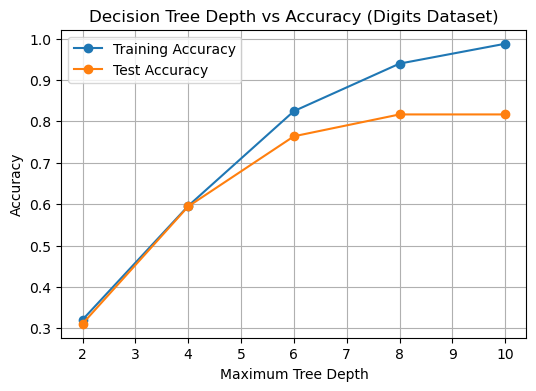

In [512]:
# Plot training vs test accuracy

plt.figure(figsize=(6, 4))
plt.plot(depths, train_accs, marker="o", label="Training Accuracy")
plt.plot(depths, test_accs, marker="o", label="Test Accuracy")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy (Digits Dataset)")
plt.legend()
plt.grid(True)
plt.show()

The results show that training accuracy increases steadily as tree depth increases, eventually reaching perfect accuracy for deep or unrestricted trees. In contrast, test accuracy peaks at a moderate depth and then declines as the tree becomes deeper.

This behaviour demonstrates overfitting: deeper trees memorise the training data but generalise poorly to unseen samples. A moderate tree depth provides the best balance between bias and variance for the Digits dataset.

#### 4.3.3 Comparison of K-Means and Decision Tree Performance (Digits Dataset)

In this section, the performance of unsupervised K-Means clustering is compared with the supervised Decision Tree classifier on the Digits dataset. The comparison highlights the impact of supervision and model choice on a complex multi-class classification problem.

In [516]:
# 4.3.3 Model comparison table (Digits dataset)

comparison_digits_models_df = pd.DataFrame({
    "Model": [
        "K-Means (Raw Scaled Data)",
        "K-Means (PCA 10D)",
        "Decision Tree (Best Depth)"
    ],
    "Test Accuracy": [
        acc_digits_raw,
        acc_digits_pca,
        max(test_accs)
    ]
})

comparison_digits_models_df

,Model,Test Accuracy
0,K-Means (Raw Scaled Data),0.617140
1,K-Means (PCA 10D),0.647746
2,Decision Tree (Best Depth),0.822222


The Decision Tree classifier achieves the highest accuracy, reflecting the advantage of supervised learning when true class labels are available during training.

K-Means clustering performs significantly worse due to the high dimensionality and strong overlap between digit classes. Applying PCA improves K-Means performance by reducing noise and redundancy, but clustering accuracy remains limited compared to the supervised approach.

#### 4.4 Summary of Digits Experiments

The Digits dataset is more challenging than the Breast Cancer dataset due to its higher dimensionality and multi-class structure.

PCA showed that variance is spread across many components, and low-dimensional projections do not provide clear class separation. While PCA improved K-Means clustering performance, substantial overlap between digit classes remained.

K-Means achieved limited accuracy, indicating that the Digits data does not exhibit a strong natural clustering structure. In contrast, the supervised Decision Tree classifier performed significantly better, with moderate tree depths providing the best generalisation.

Overall, supervised learning is far more effective than unsupervised clustering for handwritten digit classification.


## 5. Overall Summary and Interpretation

This section presents a consolidated interpretation of the experimental results obtained using PCA, K-Means clustering, and Decision Tree classification. The aim is to compare how unsupervised and supervised methods behave on datasets with different levels of complexity, and to assess the impact of dimensionality reduction on model performance.

Results are discussed separately for the Breast Cancer and Digits datasets, followed by an overall comparative evaluation.

### 5.1 Breast Cancer Dataset – Summary and Interpretation
The Breast Cancer dataset exhibits a simple and well-separated binary class structure. PCA analysis showed that a large proportion of the total variance is captured by the first few principal components, indicating that the dataset is intrinsically low-dimensional.

As a result, K-Means clustering performed well using K = 2 on both the raw scaled data and the PCA-reduced representation. The similarity in accuracy between raw and PCA-based clustering indicates that PCA preserves the most informative features while reducing dimensionality.

The supervised Decision Tree classifier achieved the highest accuracy on this dataset. However, unrestricted trees showed clear signs of overfitting, while moderate tree depths provided better generalisation. This demonstrates that even for relatively simple datasets, controlling model complexity remains important.

In [522]:
# Breast Cancer results summary table

summary_bc_df = pd.DataFrame({
    "Method": [
        "K-Means (Raw Scaled Data)",
        "K-Means (PCA 2D)",
        "Decision Tree (Best Depth)"
    ],
    "Accuracy": [
        acc_bc_raw,
        acc_bc_pca,
        max(test_accs)
    ]
})

summary_bc_df

,Method,Accuracy
0,K-Means (Raw Scaled Data),0.905097
1,K-Means (PCA 2D),0.908612
2,Decision Tree (Best Depth),0.822222


### 5.2 Digits Dataset – Summary and Interpretation
The Digits dataset represents a significantly more challenging problem due to its higher dimensionality and multi-class nature. PCA analysis showed that variance is distributed across many components, and low-dimensional projections do not provide strong class separation.

K-Means clustering achieved relatively low accuracy on the raw feature space, reflecting substantial overlap between digit classes. Applying PCA improved clustering performance by reducing noise and redundant pixel information, although clustering accuracy remained limited due to intrinsic similarities between certain digits.

The Decision Tree classifier substantially outperformed K-Means on this dataset. While training accuracy increased with tree depth, test accuracy peaked at moderate depths and then plateaued, indicating overfitting for deeper trees. This highlights the importance of controlling model complexity when dealing with complex, high-dimensional data.

In [525]:
# Digits results summary table

summary_digits_df = pd.DataFrame({
    "Method": [
        "K-Means (Raw Scaled Data)",
        "K-Means (PCA 10D)",
        "Decision Tree (Best Depth)"
    ],
    "Accuracy": [
        acc_digits_raw,
        acc_digits_pca,
        max(test_accs)
    ]
})

summary_digits_df

,Method,Accuracy
0,K-Means (Raw Scaled Data),0.617140
1,K-Means (PCA 10D),0.647746
2,Decision Tree (Best Depth),0.822222


### 5.3 Comparative Evaluation

Comparing both datasets highlights clear differences in data structure and algorithm suitability. The Breast Cancer dataset is low-dimensional and well-separated, allowing unsupervised methods such as K-Means to perform effectively. In contrast, the Digits dataset is high-dimensional and highly overlapping, limiting the effectiveness of clustering-based approaches.

Supervised learning consistently outperformed unsupervised learning, particularly for the Digits dataset. PCA was most beneficial for the Digits data, where dimensionality reduction improved clustering performance, while its impact on the Breast Cancer dataset was primarily for visualisation.

Overall, these results demonstrate that unsupervised methods are suitable for simple datasets, whereas supervised learning provides a clear advantage for complex, high-dimensional classification tasks.